In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("../Dataset/Nassau Candy Distributor.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [5]:
print("Rows and Columns:")
print(df.shape)

print("\nDataset Information:")
df.info()


Rows and Columns:
(10194, 18)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  str    
 2   Order Date      10194 non-null  str    
 3   Ship Date       10194 non-null  str    
 4   Ship Mode       10194 non-null  str    
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  str    
 7   City            10194 non-null  str    
 8   State/Province  10194 non-null  str    
 9   Postal Code     10194 non-null  str    
 10  Division        10194 non-null  str    
 11  Region          10194 non-null  str    
 12  Product ID      10194 non-null  str    
 13  Product Name    10194 non-null  str    
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  flo

In [6]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64

In [7]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

print("Dates converted successfully")

Dates converted successfully


In [8]:
df['Lead_Time'] = (
    df['Ship Date'] -
    df['Order Date']
).dt.days

df[['Order Date','Ship Date','Lead_Time']].head()

,Order Date,Ship Date,Lead_Time
0,2024-01-03,2026-06-30,909
1,2024-01-04,2026-07-01,909
2,2024-01-04,2026-07-01,909
3,2024-01-04,2026-07-01,909
4,2024-01-05,2026-07-05,912


In [9]:
df['Lead_Time'].describe()

count    10194.000000
mean      1320.841868
std        262.444892
min        904.000000
25%       1271.000000
50%       1274.000000
75%       1638.000000
max       1642.000000
Name: Lead_Time, dtype: float64

In [10]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Lead_Time
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,909
1,2,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,909
2,3,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,909
3,4,US-2021-112326-CHO-SCR-58000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,909
4,5,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,912


In [11]:
df['Profit_Margin'] = (
    df['Gross Profit'] /
    df['Sales']
) * 100

df[['Sales','Gross Profit','Profit_Margin']].head()

,Sales,Gross Profit,Profit_Margin
0,6.50,4.22,64.923077
1,7.50,4.90,65.333333
2,10.47,7.47,71.346705
3,10.80,7.50,69.444444
4,11.25,7.35,65.333333


In [12]:
df[['Sales','Gross Profit','Cost','Profit_Margin']].describe()

,Sales,Gross Profit,Cost,Profit_Margin
count,10194.000000,10194.000000,10194.000000,10194.000000
mean,13.908537,9.166451,4.742087,66.514045
std,11.341020,6.643740,5.061647,6.721012
min,1.250000,0.250000,0.600000,7.692308
25%,7.200000,4.900000,2.400000,65.333333
50%,10.800000,7.470000,3.600000,66.666667
75%,18.000000,12.250000,5.700000,69.444444
max,260.000000,130.000000,130.000000,80.000000


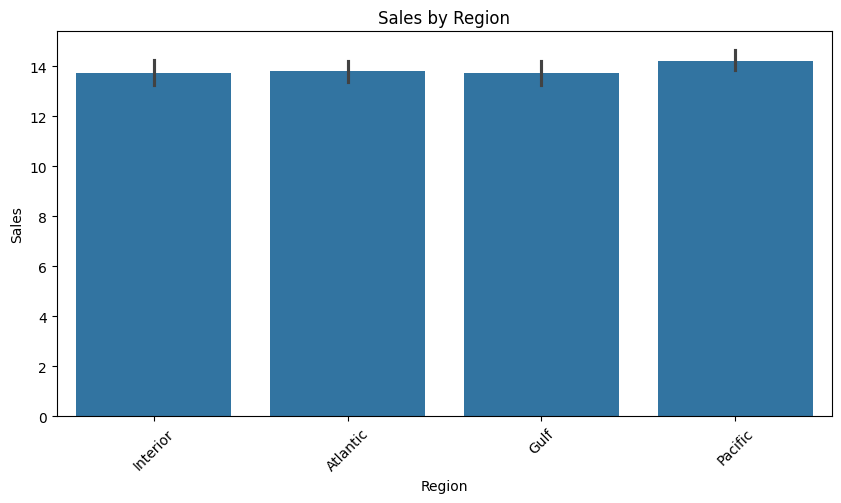

In [13]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x='Region',
    y='Sales'
)

plt.title("Sales by Region")

plt.xticks(rotation=45)

plt.show()

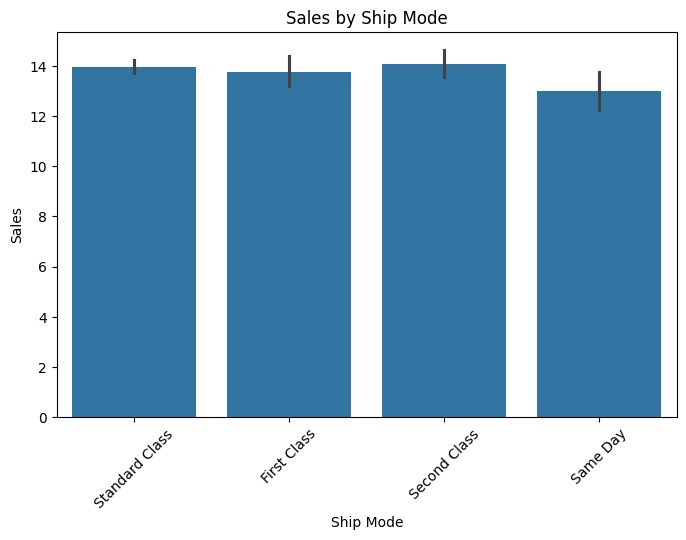

In [14]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Ship Mode',
    y='Sales'
)

plt.title("Sales by Ship Mode")
plt.xticks(rotation=45)

plt.show()

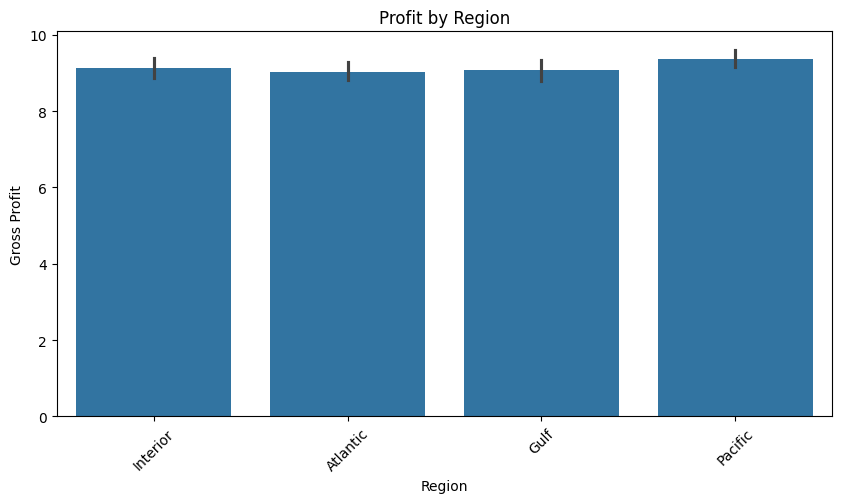

In [15]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x='Region',
    y='Gross Profit'
)

plt.title("Profit by Region")
plt.xticks(rotation=45)

plt.show()

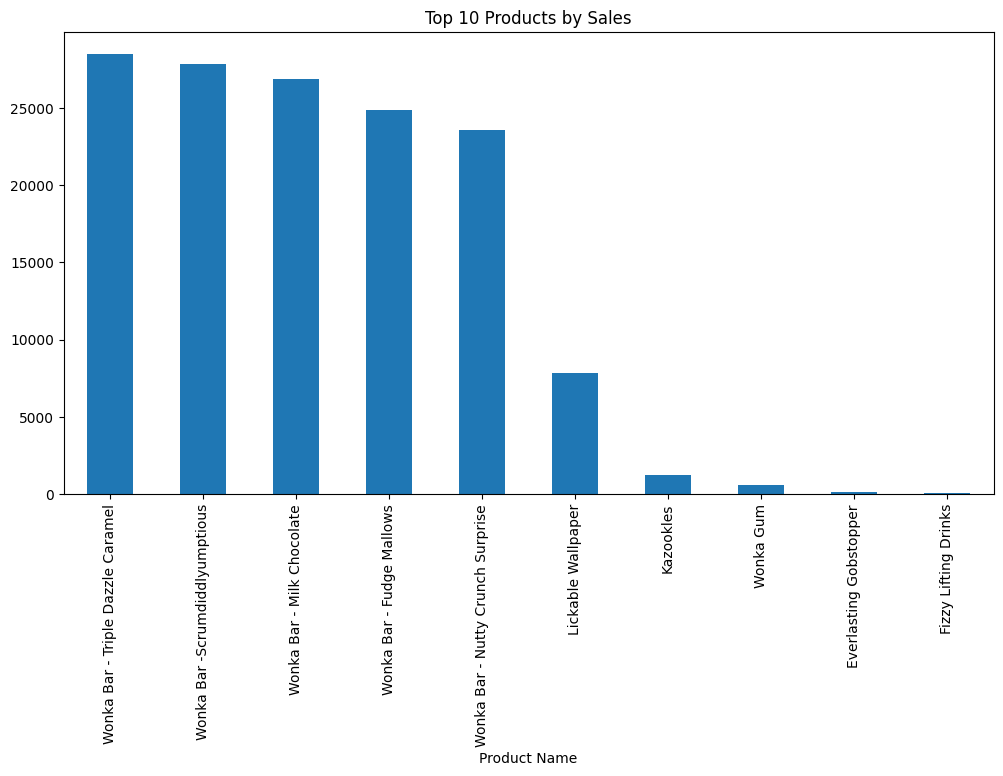

In [16]:
top_products = df.groupby(
    'Product Name'
)['Sales'].sum().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

top_products.plot(kind='bar')

plt.title("Top 10 Products by Sales")

plt.show()

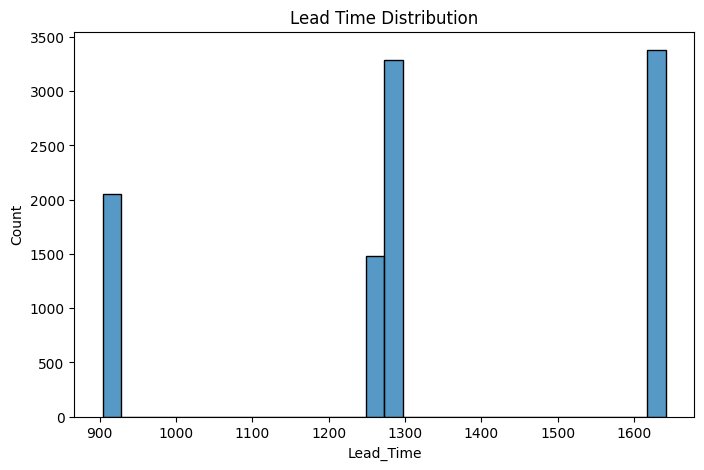

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Lead_Time'],
    bins=30
)

plt.title("Lead Time Distribution")

plt.show()

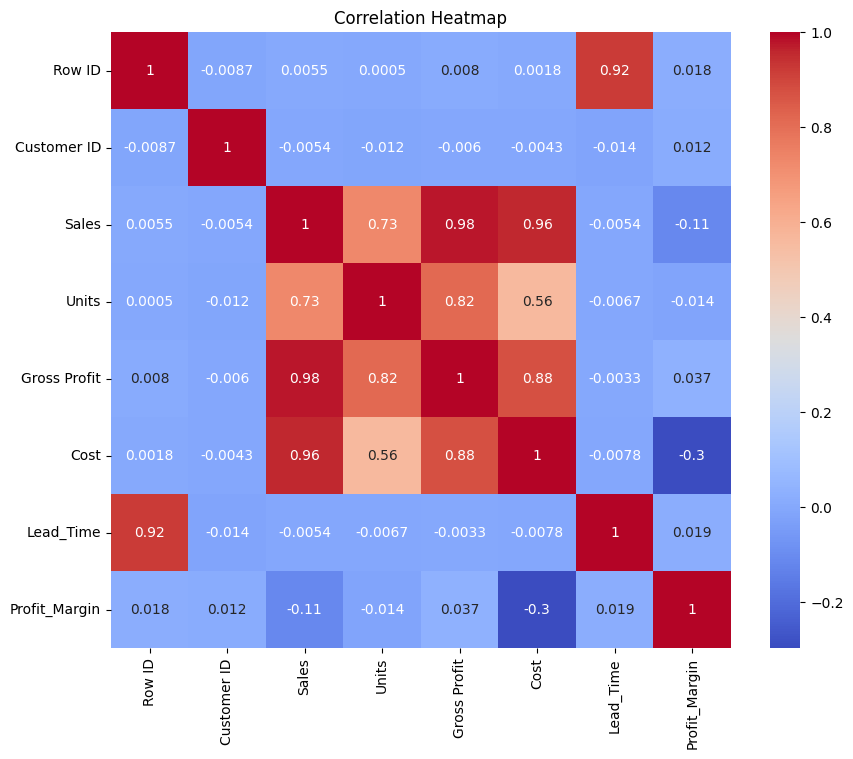

In [18]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [19]:
factory_map = {

'Wonka Bar - Nutty Crunch Surprise':'Lot\'s O\' Nuts',
'Wonka Bar - Fudge Mallows':'Lot\'s O\' Nuts',
'Wonka Bar -Scrumdiddlyumptious':'Lot\'s O\' Nuts',

'Wonka Bar - Milk Chocolate':'Wicked Choccy\'s',
'Wonka Bar - Triple Dazzle Caramel':'Wicked Choccy\'s',

'Laffy Taffy':'Sugar Shack',
'SweeTARTS':'Sugar Shack',
'Nerds':'Sugar Shack',
'Fun Dip':'Sugar Shack',
'Fizzy Lifting Drinks':'Sugar Shack',

'Everlasting Gobstopper':'Secret Factory',

'Hair Toffee':'The Other Factory',

'Lickable Wallpaper':'Secret Factory',
'Wonka Gum':'Secret Factory',

'Kazookles':'The Other Factory'
}

In [20]:
df['Factory'] = df['Product Name'].map(factory_map)

df[['Product Name','Factory']].head(20)

,Product Name,Factory
0,Wonka Bar - Milk Chocolate,Wicked Choccy's
1,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's
2,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts
3,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts
4,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's
5,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts
6,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's
7,Wonka Bar - Milk Chocolate,Wicked Choccy's
8,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts
9,Wonka Bar - Milk Chocolate,Wicked Choccy's


In [21]:
df['Factory'].isnull().sum()

np.int64(0)

In [22]:
df['Factory'].isnull().sum()

np.int64(0)

In [23]:
df['Factory'].value_counts()

Factory
Lot's O' Nuts        5692
Wicked Choccy's      4152
Secret Factory        217
The Other Factory     100
Sugar Shack            33
Name: count, dtype: int64

In [24]:
factory_sales = df.groupby(
    'Factory'
)['Sales'].sum().sort_values(
    ascending=False
)

factory_sales

Factory
Lot's O' Nuts        76340.15
Wicked Choccy's      55352.75
Secret Factory        8587.50
The Other Factory     1282.25
Sugar Shack            220.98
Name: Sales, dtype: float64

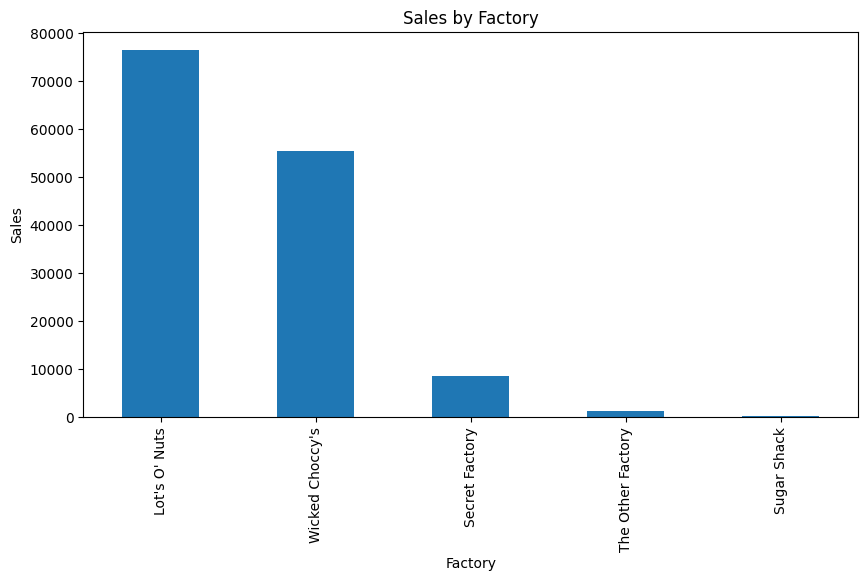

In [25]:
plt.figure(figsize=(10,5))

factory_sales.plot(
    kind='bar'
)

plt.title("Sales by Factory")

plt.ylabel("Sales")

plt.show()

In [26]:
factory_profit = df.groupby(
    'Factory'
)['Gross Profit'].sum().sort_values(
    ascending=False
)

factory_profit

Factory
Lot's O' Nuts        52771.05
Wicked Choccy's      36053.57
Secret Factory        4344.70
The Other Factory      152.25
Sugar Shack            121.23
Name: Gross Profit, dtype: float64

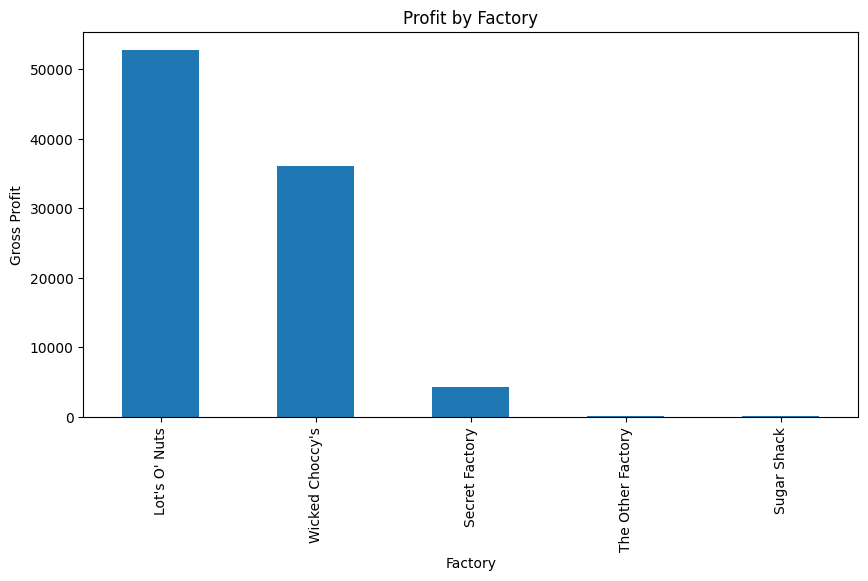

In [27]:
plt.figure(figsize=(10,5))

factory_profit.plot(
    kind='bar'
)

plt.title("Profit by Factory")

plt.ylabel("Gross Profit")

plt.show()

In [28]:
factory_coordinates = {

"Lot's O' Nuts": (32.881893, -111.768036),

"Wicked Choccy's": (32.076176, -81.088371),

"Sugar Shack": (48.11914, -96.18115),

"Secret Factory": (41.446333, -90.565487),

"The Other Factory": (35.1175, -89.971107)

}

In [29]:
df['Factory'].value_counts()

Factory
Lot's O' Nuts        5692
Wicked Choccy's      4152
Secret Factory        217
The Other Factory     100
Sugar Shack            33
Name: count, dtype: int64

In [30]:
df_encoded = pd.get_dummies(
    df,
    columns=[
        'Ship Mode',
        'Region',
        'Division',
        'Product Name',
        'Factory'
    ],
    drop_first=True
)

print(df_encoded.shape)

(10194, 42)


In [31]:
X = df_encoded.drop(
    [
        'Lead_Time',
        'Order Date',
        'Ship Date',
        'Order ID'
    ],
    axis=1
)

y = df_encoded['Lead_Time']

print(X.shape)
print(y.shape)

(10194, 38)
(10194,)


In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(8155, 38)
(2039, 38)


In [33]:
X.select_dtypes(include=['object']).columns

C:\Users\Ashutosh Sharma\AppData\Local\Temp\ipykernel_20860\754427252.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X.select_dtypes(include=['object']).columns


Index(['Country/Region', 'City', 'State/Province', 'Postal Code',
       'Product ID'],
      dtype='str')

In [34]:
X.select_dtypes(include=['object']).columns

C:\Users\Ashutosh Sharma\AppData\Local\Temp\ipykernel_20860\754427252.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X.select_dtypes(include=['object']).columns


Index(['Country/Region', 'City', 'State/Province', 'Postal Code',
       'Product ID'],
      dtype='str')

In [35]:
X = df_encoded.drop(
    [
        'Lead_Time',
        'Order Date',
        'Ship Date',
        'Order ID',
        'Country/Region',
        'City',
        'State/Province',
        'Postal Code',
        'Product ID'
    ],
    axis=1
)

print(X.shape)

(10194, 33)


In [36]:
X.select_dtypes(include=['object']).columns

Index([], dtype='str')

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(8155, 33)
(2039, 33)


In [38]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Linear Regression Completed")

Linear Regression Completed


In [39]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

def evaluate(y_true, y_pred):

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mae = mean_absolute_error(
        y_true, y_pred
    )

    r2 = r2_score(
        y_true, y_pred
    )

    return rmse, mae, r2

In [40]:
evaluate(
    y_test,
    pred_lr
)

(np.float64(100.25376486781906), 84.74149422165257, 0.8578800980172118)

In [41]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest Completed")

Random Forest Completed


In [42]:
evaluate(
    y_test,
    pred_rf
)

(np.float64(0.834512982287676), 0.6231240804315817, 0.9999901526423349)

In [43]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    random_state=42
)

gb.fit(X_train, y_train)

pred_gb = gb.predict(X_test)

print("Gradient Boosting Completed")

Gradient Boosting Completed


In [44]:
evaluate(
    y_test,
    pred_gb
)

(np.float64(0.973501803845028), 0.7883637484421926, 0.9999865993137617)

In [45]:
cluster_data = df[
    [
        'Lead_Time',
        'Sales',
        'Profit_Margin'
    ]
]

In [46]:
from sklearn.cluster import KMeans

In [47]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

df['Cluster'] = kmeans.fit_predict(
    cluster_data
)

print("Clustering Completed")

Clustering Completed


In [48]:
df['Cluster'].value_counts()

Cluster
0    4764
1    3379
2    2051
Name: count, dtype: int64

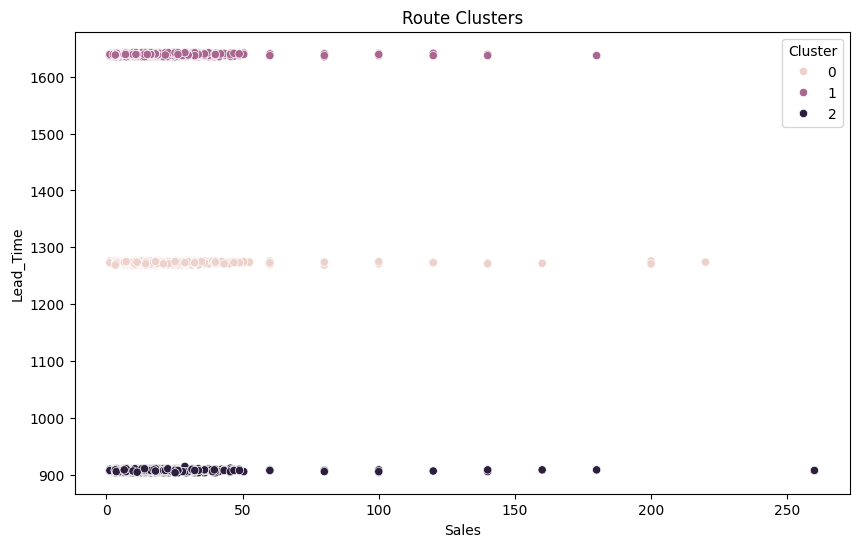

In [49]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Sales',
    y='Lead_Time',
    hue='Cluster'
)

plt.title("Route Clusters")

plt.show()

In [50]:
product_summary = df.groupby(
    ['Product Name','Factory']
).agg({
    'Sales':'sum',
    'Gross Profit':'sum',
    'Lead_Time':'mean'
}).reset_index()

product_summary.head()

,Product Name,Factory,Sales,Gross Profit,Lead_Time
0,Everlasting Gobstopper,Secret Factory,130.00,104.00,1394.666667
1,Fizzy Lifting Drinks,Sugar Shack,78.75,47.25,1273.500000
2,Fun Dip,Sugar Shack,12.00,4.80,1272.666667
3,Hair Toffee,The Other Factory,76.50,59.50,1455.250000
4,Kazookles,The Other Factory,1205.75,92.75,1272.989583


In [51]:
product_summary.sort_values(
    by='Lead_Time',
    ascending=False
).head(10)

,Product Name,Factory,Sales,Gross Profit,Lead_Time
3,Hair Toffee,The Other Factory,76.50,59.50,1455.250000
0,Everlasting Gobstopper,Secret Factory,130.00,104.00,1394.666667
8,SweeTARTS,Sugar Shack,61.50,28.70,1383.500000
5,Laffy Taffy,Sugar Shack,53.73,33.48,1383.100000
6,Lickable Wallpaper,Secret Factory,7860.00,3930.00,1339.138298
11,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,23574.95,16819.95,1328.915470
12,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,28485.00,18610.20,1325.661042
13,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,27874.80,19357.50,1320.641957
10,Wonka Bar - Milk Chocolate,Wicked Choccy's,26867.75,17443.37,1316.764623
9,Wonka Bar - Fudge Mallows,Lot's O' Nuts,24890.40,16593.60,1314.242024


In [52]:
product_summary['Recommendation_Score'] = (
    product_summary['Gross Profit']
    /
    product_summary['Lead_Time']
)

In [53]:
recommendations = product_summary.sort_values(
    by='Recommendation_Score',
    ascending=False
)

recommendations.head(10)

,Product Name,Factory,Sales,Gross Profit,Lead_Time,Recommendation_Score
13,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,27874.80,19357.50,1320.641957,14.657644
12,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,28485.00,18610.20,1325.661042,14.038430
10,Wonka Bar - Milk Chocolate,Wicked Choccy's,26867.75,17443.37,1316.764623,13.247144
11,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,23574.95,16819.95,1328.915470,12.656900
9,Wonka Bar - Fudge Mallows,Lot's O' Nuts,24890.40,16593.60,1314.242024,12.625985
6,Lickable Wallpaper,Secret Factory,7860.00,3930.00,1339.138298,2.934723
14,Wonka Gum,Secret Factory,597.50,310.70,1306.525000,0.237806
0,Everlasting Gobstopper,Secret Factory,130.00,104.00,1394.666667,0.074570
4,Kazookles,The Other Factory,1205.75,92.75,1272.989583,0.072860
3,Hair Toffee,The Other Factory,76.50,59.50,1455.250000,0.040886


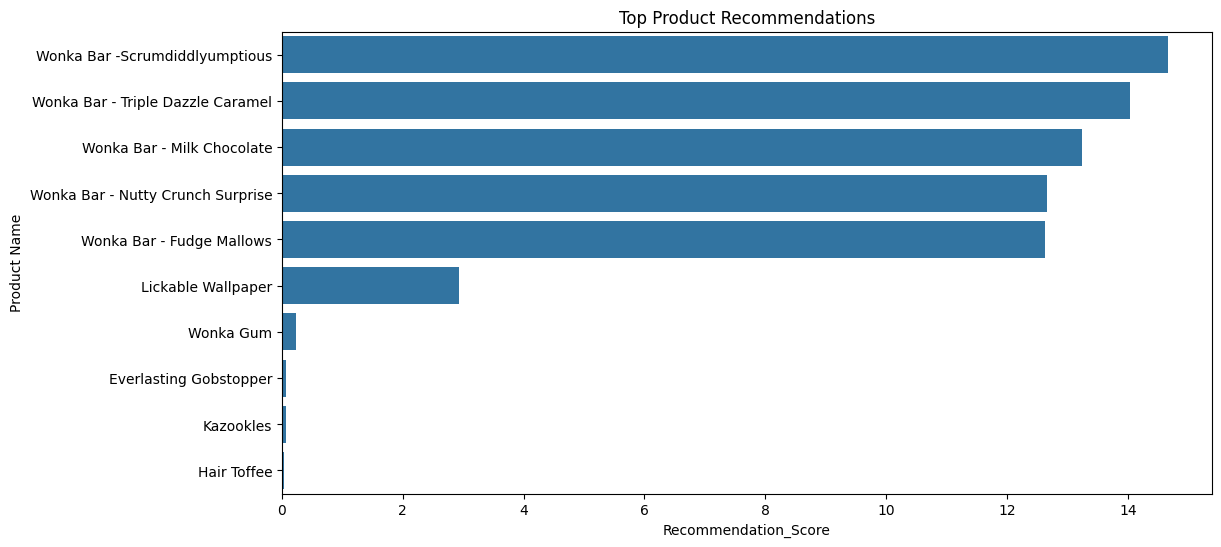

In [54]:
top10 = recommendations.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x='Recommendation_Score',
    y='Product Name'
)

plt.title(
    "Top Product Recommendations"
)

plt.show()

In [55]:
recommendations.to_csv(
    'Top_Recommendations.csv',
    index=False
)

print(
    "Recommendations exported successfully"
)

Recommendations exported successfully


In [56]:
recommendations.to_csv(
    '../Reports/Top_Recommendations.csv',
    index=False
)

print("File Saved")

File Saved


In [57]:
comparison = pd.DataFrame({

'Model':[
    'Linear Regression',
    'Random Forest',
    'Gradient Boosting'
],

'RMSE':[
    100.2538,
    0.8345,
    0.9735
],

'MAE':[
    84.7415,
    0.6231,
    0.7884
],

'R2':[
    0.8579,
    0.99999,
    0.99999
]

})

comparison

,Model,RMSE,MAE,R2
0,Linear Regression,100.2538,84.7415,0.85790
1,Random Forest,0.8345,0.6231,0.99999
2,Gradient Boosting,0.9735,0.7884,0.99999


In [58]:
comparison.to_csv(
    '../Reports/Model_Comparison.csv',
    index=False
)

print("Model Comparison Saved")

Model Comparison Saved
